# DoRothEA TF-Target Interactions Preprocessing for QuVINE

This notebook helps you:

1. Download DoRothEA TF-target interactions from OmniPath
2. Filter to high-confidence interactions (A/B levels)
3. Convert to a clean undirected NetworkX graph
4. Extract repeated **connected induced subgraphs** of approximately **5k–20k nodes**
5. Use a degree-aware sampling heuristic to better preserve the original degree distribution
6. Save sampled subgraphs as edge lists and metadata for downstream QuVINE processing

## Design choices

- **Data source**: OmniPath DoRothEA dataset (human by default)
- **Confidence filtering**: A/B levels (highest confidence)
- **Sampling goal**: connected, induced, degree-aware, repeated multiple times (e.g. 5 or 10 replicas)
- **Output format**: CSV edgelists + JSON metadata

## 1. Environment and imports

In [ ]:
# Install missing packages if needed
# %pip install pandas networkx numpy matplotlib scipy tqdm requests

In [13]:
from __future__ import annotations

import json
import math
from collections import Counter, deque
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

## 2. Configuration

In [14]:
# DoRothEA data source
# Note: To get confidence levels, you may need to use the dorothea_levels parameter
# or access DoRothEA directly from the R package or other sources
DOROTHEA_URL = "https://omnipathdb.org/interactions?datasets=dorothea&format=tsv"

# Alternative: Try to get DoRothEA with confidence levels
# DOROTHEA_URL = "https://omnipathdb.org/interactions?datasets=dorothea&dorothea_levels=A,B&format=tsv"

# Confidence levels to keep (A = highest, B = high)
# Note: If confidence levels are not in the data, the notebook will use all interactions
CONFIDENCE_LEVELS = ["A", "B"]

# Option to pre-filter by confidence in the URL (recommended)
USE_PREFILTERED_URL = True  # Set to True to download only A/B confidence levels

# Output location
OUTPUT_DIR = Path("/dccstor/cgq4hls/Q/dorothea_graph_samples")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Sampling settings
TARGET_SIZES = [5000, 10000, 20000]
REPEATS = 5  # set to 10 if desired
BASE_SEED = 42

# Degree-aware sampling heuristic settings
RESTART_PROB = 0.15
FRONTIER_WIDTH = 256
DEGREE_WEIGHT_POWER = 0.5  # >0 prefers higher-degree anchors somewhat
LOCAL_BFS_EXPANSION = 8

## 3. Download and inspect DoRothEA data

In [15]:
# Download DoRothEA TF-target interactions
# Adjust URL based on whether to pre-filter by confidence
if USE_PREFILTERED_URL:
    # Request only A and B confidence levels from OmniPath
    url = "https://omnipathdb.org/interactions?datasets=dorothea&dorothea_levels=A,B&format=tsv"
    print(f"Downloading DoRothEA data (pre-filtered to A/B confidence) from: {url}")
else:
    url = DOROTHEA_URL
    print(f"Downloading DoRothEA data (all confidence levels) from: {url}")

dorothea = pd.read_csv(url, sep="\t")

print(f"\nDataset shape: {dorothea.shape}")
print(f"\nFirst 20 columns: {list(dorothea.columns[:20])}")
print(f"\nAll columns: {list(dorothea.columns)}")
dorothea.head()


Dataset shape: (15267, 8)

First 20 columns: ['source', 'target', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']

All columns: ['source', 'target', 'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction', 'consensus_stimulation', 'consensus_inhibition']


,source,target,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition
0,P01106,O14746,True,True,False,True,True,False
1,P84022,P05412,True,True,False,True,True,False
2,Q13485,P05412,True,True,False,True,True,False
3,P08047,P04075,True,True,False,True,True,False
4,P04637,P08069,True,False,True,True,False,True


## 4. Identify confidence column and filter to high-confidence interactions

In [16]:
# Show all columns to help identify the right ones
print("All available columns:")
for i, col in enumerate(dorothea.columns, 1):
    print(f"  {i}. {col}")

# Inspect available columns related to confidence/level
conf_related_cols = [c for c in dorothea.columns if "conf" in c.lower() or "level" in c.lower() or "dorothea" in c.lower()]
print(f"\nConfidence-related columns: {conf_related_cols}")

# Try to automatically detect the confidence column
conf_col = None
# Common column names in OmniPath DoRothEA
for col in ["dorothea_level", "confidence", "level", "confidence_level", "dorothea_curated", "extra_attrs"]:
    if col in dorothea.columns:
        conf_col = col
        break

if conf_col is None and conf_related_cols:
    conf_col = conf_related_cols[0]

if conf_col:
    print(f"\nUsing confidence column: '{conf_col}'")
    print(f"Unique values: {sorted(dorothea[conf_col].unique())}")
    print(f"Value counts:\n{dorothea[conf_col].value_counts()}")
else:
    if USE_PREFILTERED_URL:
        print("\n✓ No confidence column needed - data was pre-filtered to A/B levels via URL parameter")
    else:
        print("\nWARNING: Could not automatically detect confidence column.")
        print("Please inspect the columns above and manually set conf_col.")
        print("\nFor example, if the confidence info is in 'extra_attrs', you may need to parse it.")
        print("Or if DoRothEA levels are embedded in another column, extract them first.")
        print("\nAlternatively, set USE_PREFILTERED_URL=True to download only A/B levels directly.")

All available columns:
  1. source
  2. target
  3. is_directed
  4. is_stimulation
  5. is_inhibition
  6. consensus_direction
  7. consensus_stimulation
  8. consensus_inhibition

Confidence-related columns: []

✓ No confidence column needed - data was pre-filtered to A/B levels via URL parameter


### Optional: Parse confidence from extra_attrs if needed

If the confidence column wasn't found, it might be embedded in a JSON/dict column like `extra_attrs`. Uncomment and run this cell if needed:

In [17]:
# # Uncomment if you need to parse confidence from extra_attrs or similar column
# import json
# 
# if 'extra_attrs' in dorothea.columns and conf_col is None:
#     # Try to extract dorothea_level from extra_attrs
#     def extract_dorothea_level(extra_attrs):
#         if pd.isna(extra_attrs):
#             return None
#         try:
#             if isinstance(extra_attrs, str):
#                 attrs = json.loads(extra_attrs)
#             else:
#                 attrs = extra_attrs
#             return attrs.get('dorothea_level', None)
#         except:
#             return None
#     
#     dorothea['dorothea_level'] = dorothea['extra_attrs'].apply(extract_dorothea_level)
#     conf_col = 'dorothea_level'
#     print(f"Extracted confidence levels from extra_attrs")
#     print(f"Value counts:\n{dorothea[conf_col].value_counts()}")

In [18]:
# Filter to high-confidence interactions (A/B)
if conf_col:
    dorothea_ab = dorothea[dorothea[conf_col].isin(CONFIDENCE_LEVELS)].copy()
    print(f"Original dataset: {dorothea.shape[0]} interactions")
    print(f"After filtering to {CONFIDENCE_LEVELS}: {dorothea_ab.shape[0]} interactions")
    print(f"Reduction: {100 * (1 - dorothea_ab.shape[0] / dorothea.shape[0]):.1f}%")
elif USE_PREFILTERED_URL:
    # Already pre-filtered by URL parameter
    dorothea_ab = dorothea.copy()
    print(f"Using pre-filtered data from URL (A/B confidence levels)")
    print(f"Total interactions: {dorothea_ab.shape[0]}")
else:
    # No filtering - use all interactions
    dorothea_ab = dorothea.copy()
    print(f"Using all interactions (no confidence filtering)")
    print(f"Total interactions: {dorothea_ab.shape[0]}")
    print(f"\nNote: To filter by confidence, either:")
    print(f"  1. Set USE_PREFILTERED_URL=True to download only A/B levels")
    print(f"  2. Or manually set conf_col if confidence info is in the data")

Using pre-filtered data from URL (A/B confidence levels)
Total interactions: 15267


## 5. Identify source and target columns

In [19]:
# Common column name patterns for TF-target interactions
source_candidates = ["source", "source_genesymbol", "tf", "transcription_factor", "regulator"]
target_candidates = ["target", "target_genesymbol", "gene", "target_gene", "regulated"]

source_col = None
target_col = None

# Try to find source column
for col in source_candidates:
    if col in dorothea_ab.columns:
        source_col = col
        break

# Try to find target column
for col in target_candidates:
    if col in dorothea_ab.columns:
        target_col = col
        break

if source_col and target_col:
    print(f"Source column: '{source_col}'")
    print(f"Target column: '{target_col}'")
    print(f"\nSample interactions:")
    print(dorothea_ab[[source_col, target_col]].head(10))
else:
    print("Could not automatically detect source/target columns.")
    print("Available columns:", list(dorothea_ab.columns))
    print("\nPlease manually set source_col and target_col variables.")

Source column: 'source'
Target column: 'target'

Sample interactions:
   source  target
0  P01106  O14746
1  P84022  P05412
2  Q13485  P05412
3  P08047  P04075
4  P04637  P08069
5  Q05516  P20248
6  Q01196  P08700
7  P42224  P38936
8  P40763  P38936
9  Q04206  P08183


## 6. Build NetworkX graph from DoRothEA interactions

In [20]:
def build_graph_from_dorothea(df: pd.DataFrame, source_col: str, target_col: str) -> nx.Graph:
    """
    Build an undirected NetworkX graph from DoRothEA TF-target interactions.
    
    Args:
        df: DataFrame with TF-target interactions
        source_col: Column name for transcription factors
        target_col: Column name for target genes
    
    Returns:
        Undirected simple graph (no self-loops, no multi-edges)
    """
    # Create directed graph first (TF -> target)
    G_directed = nx.DiGraph()
    
    for _, row in df.iterrows():
        tf = str(row[source_col]).strip()
        target = str(row[target_col]).strip()
        
        # Skip invalid entries
        if tf and target and tf != 'nan' and target != 'nan':
            G_directed.add_edge(tf, target)
    
    # Convert to undirected and remove self-loops
    G = G_directed.to_undirected()
    G.remove_edges_from(nx.selfloop_edges(G))
    
    return G


def keep_largest_connected_component(G: nx.Graph) -> nx.Graph:
    """Extract the largest connected component."""
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G.copy()
    lcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(lcc_nodes).copy()


# Build the graph
if source_col and target_col:
    G_full = build_graph_from_dorothea(dorothea_ab, source_col, target_col)
    G_full = keep_largest_connected_component(G_full)
    
    print(f"Graph built successfully!")
    print(f"Graph type: {type(G_full).__name__} (undirected={not G_full.is_directed()})")
    print(f"Nodes: {G_full.number_of_nodes()}")
    print(f"Edges: {G_full.number_of_edges()}")
    print(f"Connected: {nx.is_connected(G_full)}")
    print(f"Average degree: {2 * G_full.number_of_edges() / G_full.number_of_nodes():.2f}")
    
    # Verify it's undirected
    assert not G_full.is_directed(), "ERROR: Graph should be undirected!"
    print("\n✓ Verified: Graph is undirected")
else:
    print("Cannot build graph - source/target columns not identified")

Graph built successfully!
Graph type: Graph (undirected=True)
Nodes: 5252
Edges: 15192
Connected: True
Average degree: 5.79

✓ Verified: Graph is undirected


## 7. Graph analysis helpers

In [21]:
def graph_degree_array(G: nx.Graph) -> np.ndarray:
    if G.number_of_nodes() == 0:
        return np.array([], dtype=float)
    return np.array([d for _, d in G.degree()], dtype=float)


def summarize_graph(G: nx.Graph) -> Dict[str, float]:
    deg = graph_degree_array(G)
    return {
        "num_nodes": int(G.number_of_nodes()),
        "num_edges": int(G.number_of_edges()),
        "avg_degree": float(deg.mean()) if len(deg) else 0.0,
        "median_degree": float(np.median(deg)) if len(deg) else 0.0,
        "max_degree": float(deg.max()) if len(deg) else 0.0,
        "num_connected_components": int(nx.number_connected_components(G)),
    }


def plot_degree_ccdf(graphs: Dict[str, nx.Graph], title: str = "Degree CCDF comparison"):
    plt.figure(figsize=(7, 5))
    for label, G in graphs.items():
        deg = graph_degree_array(G)
        deg = deg[deg > 0]
        if len(deg) == 0:
            continue
        xs = np.sort(np.unique(deg))
        ccdf = np.array([(deg >= x).mean() for x in xs])
        plt.step(xs, ccdf, where="post", label=label)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree")
    plt.ylabel("CCDF")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def degree_histogram_distance(G_ref: nx.Graph, G_sub: nx.Graph, bins: int = 30) -> float:
    deg_ref = graph_degree_array(G_ref)
    deg_sub = graph_degree_array(G_sub)
    if len(deg_ref) == 0 or len(deg_sub) == 0:
        return float("inf")
    upper = max(float(deg_ref.max()), float(deg_sub.max()), 1.0)
    bin_edges = np.linspace(0.0, upper, bins + 1)
    h_ref, _ = np.histogram(deg_ref, bins=bin_edges, density=True)
    h_sub, _ = np.histogram(deg_sub, bins=bin_edges, density=True)
    return float(np.abs(h_ref - h_sub).sum())


# Summarize the full graph
full_summary = summarize_graph(G_full)
print("Full DoRothEA graph summary:")
for key, value in full_summary.items():
    print(f"  {key}: {value}")

Full DoRothEA graph summary:
  num_nodes: 5252
  num_edges: 15192
  avg_degree: 5.785224676313785
  median_degree: 2.0
  max_degree: 729.0
  num_connected_components: 1


## 8. Degree-aware subgraph sampling functions

In [22]:
def induce_subgraph_by_nodes(G: nx.Graph, nodes: Iterable) -> nx.Graph:
    node_set = set(nodes)
    H = nx.Graph()
    H.add_nodes_from((n, G.nodes[n]) for n in node_set)
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if u in node_set and v in node_set)
    return H


def weighted_choice_without_replacement(items, weights, k, rng):
    items = list(items)
    weights = np.asarray(weights, dtype=float)
    if len(items) == 0:
        return []
    if np.all(weights <= 0):
        weights = np.ones(len(items), dtype=float)
    weights = np.maximum(weights, 1e-12)
    probs = weights / weights.sum()
    k_eff = min(k, len(items))
    idx = rng.choice(len(items), size=k_eff, replace=False, p=probs)
    return [items[i] for i in idx]


def sample_anchor_node(G: nx.Graph, rng: np.random.Generator, power: float = 0.5):
    nodes = list(G.nodes())
    deg = np.array([G.degree(n) for n in nodes], dtype=float)
    weights = np.power(np.maximum(deg, 1.0), power)
    weights = weights / weights.sum()
    return nodes[int(rng.choice(len(nodes), p=weights))]


def sample_degree_targets(G: nx.Graph, sample_size: int, rng: np.random.Generator) -> np.ndarray:
    deg = graph_degree_array(G)
    if len(deg) == 0:
        return np.zeros(sample_size)
    return rng.choice(deg, size=sample_size, replace=True)


def connected_degree_aware_subgraph(
    G: nx.Graph,
    target_size: int,
    rng: np.random.Generator,
    restart_prob: float = 0.15,
    degree_weight_power: float = 0.5,
    frontier_width: int = 256,
    local_bfs_expansion: int = 8,
) -> nx.Graph:
    if target_size >= G.number_of_nodes():
        return G.copy()

    anchor = sample_anchor_node(G, rng, power=degree_weight_power)
    selected = [anchor]
    selected_set = {anchor}
    frontier = set(G.adj[anchor].keys())

    degree_targets = sample_degree_targets(G, target_size, rng)
    target_ptr = 0

    while len(selected) < target_size:
        if not frontier or rng.random() < restart_prob:
            seed_from_selected = selected[int(rng.integers(0, len(selected)))]
            local_frontier = deque([seed_from_selected])
            steps = 0
            while local_frontier and steps < local_bfs_expansion:
                u = local_frontier.popleft()
                nbrs = list(G.adj[u].keys())
                rng.shuffle(nbrs)
                for v in nbrs:
                    if v not in selected_set:
                        frontier.add(v)
                        local_frontier.append(v)
                steps += 1

        if not frontier:
            remaining = list(set(G.nodes()) - selected_set)
            if not remaining:
                break
            candidate = remaining[int(rng.integers(0, len(remaining)))]
            frontier.add(candidate)

        frontier_list = list(frontier)
        if len(frontier_list) > frontier_width:
            frontier_list = weighted_choice_without_replacement(
                frontier_list,
                [max(G.degree(n), 1) for n in frontier_list],
                frontier_width,
                rng,
            )

        target_degree = degree_targets[min(target_ptr, len(degree_targets) - 1)]
        scores = []
        for node in frontier_list:
            deg = G.degree(node)
            internal_links = sum((nbr in selected_set) for nbr in G.adj[node].keys())
            degree_match = 1.0 / (1.0 + abs(deg - target_degree))
            score = 2.0 * internal_links + degree_match + 0.25 * np.log1p(deg)
            scores.append(score)

        scores = np.asarray(scores, dtype=float)
        if np.all(scores <= 0):
            scores = np.ones_like(scores)
        probs = scores / scores.sum()
        chosen_idx = int(rng.choice(len(frontier_list), p=probs))
        chosen = frontier_list[chosen_idx]

        selected.append(chosen)
        selected_set.add(chosen)
        frontier.discard(chosen)
        frontier.update(v for v in G.adj[chosen].keys() if v not in selected_set)
        target_ptr += 1

    H = induce_subgraph_by_nodes(G, selected_set)
    H = keep_largest_connected_component(H)

    # If taking LCC dropped too many nodes, greedily refill through the boundary
    while H.number_of_nodes() < target_size and H.number_of_nodes() < G.number_of_nodes():
        current_nodes = set(H.nodes())
        boundary = set()
        for u in current_nodes:
            boundary.update(v for v in G.adj[u].keys() if v not in current_nodes)
        if not boundary:
            break
        boundary = list(boundary)
        rng.shuffle(boundary)
        needed = min(target_size - H.number_of_nodes(), len(boundary))
        current_nodes.update(boundary[:needed])
        H = keep_largest_connected_component(induce_subgraph_by_nodes(G, current_nodes))

    return H


def repeated_connected_subgraph_sampling(
    G: nx.Graph,
    target_sizes: Sequence[int],
    repeats: int,
    base_seed: int = 42,
    restart_prob: float = 0.15,
    degree_weight_power: float = 0.5,
    frontier_width: int = 256,
    local_bfs_expansion: int = 8,
) -> List[Dict]:
    results = []
    for target_size in target_sizes:
        effective_target = min(target_size, G.number_of_nodes())
        for repeat_idx in range(repeats):
            seed = base_seed + 1000 * repeat_idx + int(target_size)
            rng = np.random.default_rng(seed)
            H = connected_degree_aware_subgraph(
                G,
                target_size=effective_target,
                rng=rng,
                restart_prob=restart_prob,
                degree_weight_power=degree_weight_power,
                frontier_width=frontier_width,
                local_bfs_expansion=local_bfs_expansion,
            )
            dist = degree_histogram_distance(G, H)
            results.append({
                "target_size": int(target_size),
                "effective_target_size": int(effective_target),
                "repeat_idx": int(repeat_idx),
                "seed": int(seed),
                "graph": H,
                "summary": summarize_graph(H),
                "degree_hist_l1": float(dist),
            })
    return results

## 9. Run repeated sampling

In [23]:
samples = repeated_connected_subgraph_sampling(
    G_full,
    target_sizes=TARGET_SIZES,
    repeats=REPEATS,
    base_seed=BASE_SEED,
    restart_prob=RESTART_PROB,
    degree_weight_power=DEGREE_WEIGHT_POWER,
    frontier_width=FRONTIER_WIDTH,
    local_bfs_expansion=LOCAL_BFS_EXPANSION,
)

print(f"Generated {len(samples)} sampled subgraphs")
print("\nFirst 5 samples:")
for s in samples[:5]:
    print(f"  Target: {s['target_size']}, Repeat: {s['repeat_idx']}, "
          f"Nodes: {s['summary']['num_nodes']}, Edges: {s['summary']['num_edges']}")

Generated 15 sampled subgraphs

First 5 samples:
  Target: 5000, Repeat: 0, Nodes: 5000, Edges: 14937
  Target: 5000, Repeat: 1, Nodes: 5000, Edges: 14938
  Target: 5000, Repeat: 2, Nodes: 5000, Edges: 14937
  Target: 5000, Repeat: 3, Nodes: 5000, Edges: 14939
  Target: 5000, Repeat: 4, Nodes: 5000, Edges: 14940


## 10. Review sample quality

In [24]:
quality_rows = []
for s in samples:
    row = {
        "target_size": s["target_size"],
        "effective_target_size": s["effective_target_size"],
        "repeat_idx": s["repeat_idx"],
        "seed": s["seed"],
        "degree_hist_l1": s["degree_hist_l1"],
    }
    row.update(s["summary"])
    quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows).sort_values(["target_size", "repeat_idx"])
quality_df

,target_size,effective_target_size,repeat_idx,seed,degree_hist_l1,num_nodes,num_edges,avg_degree,median_degree,max_degree,num_connected_components
0,5000,5000,0,5042,0.000191,5000,14937,5.974800,2.0,710.0,1
1,5000,5000,1,6042,0.000135,5000,14938,5.975200,2.0,708.0,1
2,5000,5000,2,7042,0.000135,5000,14937,5.974800,2.0,706.0,1
3,5000,5000,3,8042,0.000146,5000,14939,5.975600,2.0,709.0,1
4,5000,5000,4,9042,0.000177,5000,14940,5.976000,2.0,712.0,1
5,10000,5252,0,10042,0.000000,5252,15192,5.785225,2.0,729.0,1
6,10000,5252,1,11042,0.000000,5252,15192,5.785225,2.0,729.0,1
7,10000,5252,2,12042,0.000000,5252,15192,5.785225,2.0,729.0,1
8,10000,5252,3,13042,0.000000,5252,15192,5.785225,2.0,729.0,1
9,10000,5252,4,14042,0.000000,5252,15192,5.785225,2.0,729.0,1


In [25]:
# Summary statistics by target size
quality_df.groupby("target_size")["degree_hist_l1"].agg(["mean", "std", "min", "max"]).reset_index()

,target_size,mean,std,min,max
0,5000,0.000157,0.000026,0.000135,0.000191
1,10000,0.000000,0.000000,0.000000,0.000000
2,20000,0.000000,0.000000,0.000000,0.000000


In [26]:
# Best sample per target size (lowest degree histogram distance)
best_per_size = (
    quality_df.sort_values("degree_hist_l1")
    .groupby("target_size", as_index=False)
    .first()
)
best_per_size

,target_size,effective_target_size,repeat_idx,seed,degree_hist_l1,num_nodes,num_edges,avg_degree,median_degree,max_degree,num_connected_components
0,5000,5000,1,6042,0.000135,5000,14938,5.975200,2.0,708.0,1
1,10000,5252,1,11042,0.000000,5252,15192,5.785225,2.0,729.0,1
2,20000,5252,2,22042,0.000000,5252,15192,5.785225,2.0,729.0,1


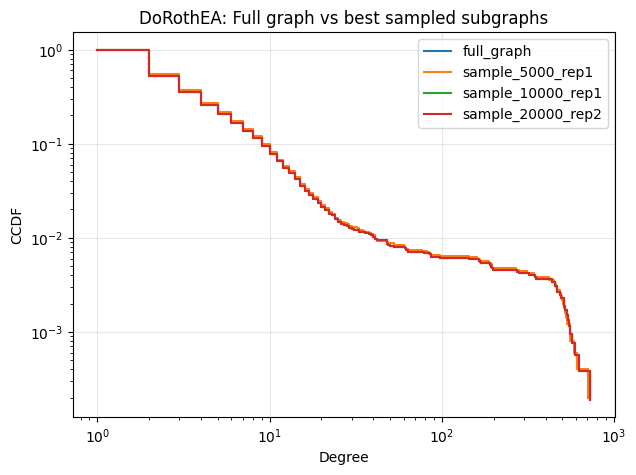

In [27]:
# Plot degree distributions
graphs_to_plot = {"full_graph": G_full}
for _, row in best_per_size.iterrows():
    match = [
        s for s in samples
        if s["target_size"] == row["target_size"] and s["repeat_idx"] == row["repeat_idx"]
    ][0]
    graphs_to_plot[f"sample_{int(row['target_size'])}_rep{int(row['repeat_idx'])}"] = match["graph"]

plot_degree_ccdf(graphs_to_plot, title="DoRothEA: Full graph vs best sampled subgraphs")

## 11. Save sampled subgraphs for QuVINE

In [28]:
def save_graph_edgelist_csv(G: nx.Graph, path: Path):
    df = pd.DataFrame(list(G.edges()), columns=["node1", "node2"])
    df.to_csv(path, index=False)


def save_sample_bundle(sample: Dict, output_dir: Path, dataset_name: str):
    graph = sample["graph"]
    target_size = sample["target_size"]
    repeat_idx = sample["repeat_idx"]
    stem = f"{dataset_name}_n{target_size}_rep{repeat_idx}"

    csv_path = output_dir / f"{stem}.csv"
    json_path = output_dir / f"{stem}.json"

    save_graph_edgelist_csv(graph, csv_path)
    metadata = {
        "dataset_name": dataset_name,
        "data_source": "OmniPath DoRothEA",
        "confidence_levels": CONFIDENCE_LEVELS,
        "target_size": int(sample["target_size"]),
        "effective_target_size": int(sample["effective_target_size"]),
        "repeat_idx": int(sample["repeat_idx"]),
        "seed": int(sample["seed"]),
        "degree_hist_l1": float(sample["degree_hist_l1"]),
        "summary": sample["summary"],
        "sampling_parameters": {
            "restart_prob": RESTART_PROB,
            "degree_weight_power": DEGREE_WEIGHT_POWER,
            "frontier_width": FRONTIER_WIDTH,
            "local_bfs_expansion": LOCAL_BFS_EXPANSION,
            "base_seed": BASE_SEED,
        },
    }
    with open(json_path, "w") as f:
        json.dump(metadata, f, indent=2)
    return csv_path, json_path


# Save all samples
saved_paths = []
for sample in tqdm(samples, desc="Saving samples"):
    saved_paths.append(save_sample_bundle(sample, OUTPUT_DIR, "dorothea"))

print(f"\nSaved {len(saved_paths)} sample bundles to {OUTPUT_DIR}")
print("\nFirst 5 saved files:")
for csv_path, json_path in saved_paths[:5]:
    print(f"  {csv_path.name}")

Saving samples:   0%|          | 0/15 [00:00<?, ?it/s]


Saved 15 sample bundles to /dccstor/cgq4hls/Q/dorothea_graph_samples

First 5 saved files:
  dorothea_n5000_rep0.csv
  dorothea_n5000_rep1.csv
  dorothea_n5000_rep2.csv
  dorothea_n5000_rep3.csv
  dorothea_n5000_rep4.csv


## 12. Optional: Save only best samples per target size

In [ ]:
# If you want to save only the best sample per target size
best_samples = []
for target_size in sorted(set(s["target_size"] for s in samples)):
    subset = [s for s in samples if s["target_size"] == target_size]
    best = min(subset, key=lambda x: x["degree_hist_l1"])
    best_samples.append(best)

print("Best samples per target size:")
for s in best_samples:
    print(f"  Target: {s['target_size']}, Repeat: {s['repeat_idx']}, "
          f"Degree L1: {s['degree_hist_l1']:.4f}")

## 13. Summary and next steps

### What we did:
1. Downloaded DoRothEA TF-target interactions from OmniPath
2. Filtered to high-confidence interactions (A/B levels)
3. Built an undirected graph from the interactions
4. Sampled multiple connected subgraphs with degree-aware sampling
5. Saved all samples as CSV edgelists + JSON metadata

### Next steps for QuVINE:
1. Point QuVINE graph-loading config to one of the saved CSV files
2. Run `prepare_graph(...)` if you want further sparsification/subsampling
3. Evaluate embeddings across multiple repeats of the sampled subgraphs

### Example usage:
```python
import pandas as pd
import networkx as nx

# Load a sample
df = pd.read_csv("../data/processed_data/dorothea_graph_samples/dorothea_n5000_rep0.csv")
G = nx.from_pandas_edgelist(df, source="node1", target="node2")
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
```